# RSoXS data reduction

## Imports and other setup

### Import PyHyperScattering and access beamline data

If accessing NSLS II data from local machine, enter BNL credentials and 2-factor authentication when prompted. The catalog will include a list of scan IDs to which you have access.

In [1]:
import PyHyperScattering as phs
print(f'Using PyHyper Version: {phs.__version__}')

loader = phs.load.SST1RSoXSDB(corr_mode="none")
catalog = loader.c
catalog

C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  File "C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start


Using PyHyper Version: 0.2.9+33.gab928ef
could not directly connect to Tiled using a system profile.
  Making network connection.
  Enter your BNL credentials now or pass an api key like catalog_kwargs={"api_key":"..."}.


<Catalog {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ...} ~96501 entries>

### Import other libraries as needed

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import sys
print(f"Python version {sys.version}.  Version info. {sys.version_info}")
import os

## Data storage and manipulation
import numpy as np
import pandas as pd
import xarray as xr ## !pip install xarray==2022.3
import math
import copy
import datetime
import inspect
import re
import scipy

## Plotting
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LogNorm ## For log scaling in imshow
from matplotlib.pyplot import cm
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
from matplotlib.colors import Normalize

Python version 3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:08:16) [MSC v.1943 64 bit (AMD64)].  Version info. sys.version_info(major=3, minor=12, micro=10, releaselevel='final', serial=0)


### Load local functions

Below are a list of functions that can assist data reduction.

In [ ]:

def view_single_image(
    scan_id,
    energy_view_image = 285,
    range_dark_subtracted_image = [None, None],
    range_light_image = [None, None],
    range_dark_image = [None, None],
):

    """
    View a single image from a scan including raw image, corresponding dark image, and dark-subtracted image.
    """
    
    HEIGHT_CAMERA_SENSOR, WIDTH_CAMERA_SENSOR = 61.4, 61.7 ## [mm]

    ## Load images
    loader = phs.load.SST1RSoXSDB(corr_mode="none", dark_subtract=True)
    scan = loader.loadRun(scan_id).unstack('system')
    scan_single_image = scan.sel(energy=energy_view_image, method="nearest")
    try: ## TODO: Likely can remove try/except after PyHyperScattering v 2.10 or later is released, which would contain fix to dark_subtract = False option
        loader_light = phs.load.SST1RSoXSDB(corr_mode="none", dark_subtract=False)
        scan_light = loader_light.loadRun(scan_id).unstack('system')
        scan_light_single_image = scan_light.sel(energy=energy_view_image, method="nearest")
        scan_dark_single_image = scan_light_single_image - scan_single_image
    except:
        scan_light_single_image = scan_light_single_image.astype(float)*np.nan
        scan_dark_single_image = scan_dark_single_image.astype(float)*np.nan
    
    
    number_rows, number_columns = 2, 3
    fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*3.25, number_rows*3.25), edgecolor=(0, 0, 0, 0), linewidth=3) #figsize=(3.25, 3.25) for figure
    ## Ensure axs always stays a 2D array
    if number_rows == 1 and number_columns == 1: axs = np.array([[axs]])
    if number_rows == 1 and number_columns > 1: axs = axs.reshape(1, number_columns)
    if number_rows > 1 and number_columns == 1: axs = axs.reshape(number_rows, 1)
    fig.suptitle(("Energy = " + str(round(scan_single_image["energy"].data.item(), 2)) + " eV"), color=(0, 0, 0, 1), fontname="Calibri", size=12)

    titles_subfigures = ["Dark-subtracted image", "Raw light image", "Raw dark image"]
    images = [scan_single_image, scan_light_single_image, scan_dark_single_image]
    ranges_intensity = [range_dark_subtracted_image, range_light_image, range_dark_image]
    for index_column in np.arange(0, number_columns, 1):
        title_subfigure, image, range_intensity = titles_subfigures[index_column], images[index_column], ranges_intensity[index_column]
        axs[0, index_column].set_title(title_subfigure, color=(0, 0, 0, 1), fontname="Calibri", size=12)
        image_linear = axs[0, index_column].imshow(image, extent=[0, WIDTH_CAMERA_SENSOR, HEIGHT_CAMERA_SENSOR, 0], cmap=matplotlib.colormaps['RdYlBu_r'], vmin=range_intensity[0], vmax=range_intensity[1])
        fig.colorbar(image_linear, ax=axs[0, index_column], shrink=0.85, aspect=20, pad=0.02)
        image_log = axs[1, index_column].imshow(image, extent=[0, WIDTH_CAMERA_SENSOR, HEIGHT_CAMERA_SENSOR, 0], cmap=matplotlib.colormaps['RdYlBu_r'], norm=LogNorm(vmin=range_intensity[0], vmax=range_intensity[1]))
        fig.colorbar(image_log, ax=axs[1, index_column], shrink=0.85, aspect=20, pad=0.02)
        
    ## Plot Formatting
    for index_row in np.arange(0, number_rows, 1):
        for index_column in np.arange(0, number_columns, 1):
            ax = axs[index_row, index_column]
            ## Subplot and axes labels
            ax.set_xlabel("Outboard-inboard (mm)", color=(0, 0, 0, 1), size=12)
            ax.set_ylabel("Down-up (mm)", color=(0, 0, 0, 1), size=12)
            ## Axes scaling and ranges
            ax.set_xscale("linear")
            ax.set_yscale("linear")
            ax.set_xlim([0, WIDTH_CAMERA_SENSOR])
            ax.set_ylim([0, HEIGHT_CAMERA_SENSOR])
            ## Border formatting
            for Border in np.array(["top", "bottom", "left", "right"]):
                ax.spines[Border].set_linewidth(2) ## axes/border linewidths
                ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
            for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis,colors=(0, 0, 0, 1), width=2)
            #ax.tick_params(axis="y", which="minor", colors=(0, 0, 0, 0), width=2)
    #ax.legend(edgecolor=(1, 1, 1, 1)) #ax.legend(ncol=1, bbox_to_anchor=(1.05,1), edgecolor=(1, 1, 1, 1)); ## Coming off the top right column
    plt.tight_layout() ## This ensures that subplots don't overlap
    plt.show()





## Search for scans

Narrow down search parameters as needed to find the desired scan from the NSLS II SST1 RSoXS station.  Various examples are shown in the comments.

If the desired scans are not found in this summary, check that you are listed as an experimenter in the beam time proposal (https://pass.bnl.gov/).

In [3]:
filtered_scan_list = loader.searchCatalog(cycle="commissioning", institution="NIST", project="calibration")
#filtered_scan_list = loader.searchCatalog(cycle="2025-1", proposal_id=317698, institution="NIST", project="calibration", sample_id="OpenBeam", plan="list_scan")

filtered_scan_list

Retrieving results...: 100%|█████████████████████████████████████████████████████████| 614/614 [00:06<00:00, 94.60it/s]
C:\Users\pmk\AppData\Local\Temp\1\ipykernel_5980\3947386088.py:1: UserWarning: One or more missing field(s) during this load were replaced with "N/A".  Re-run with debugWarnings=True to see details.
  filtered_scan_list = loader.searchCatalog(cycle="commissioning", institution="NIST", project="calibration")


,scan_id,start_time,cycle,institution,project,sample_name,sample_id,plan,detector,exit_status,num_Images
0,93903,2025-03-24 10:30:05.424809,commissioning,NIST,calibration,HOPG,HOPG,fly_max,beamstop_waxs,success,46
1,93904,2025-03-24 10:30:41.824468,commissioning,NIST,calibration,HOPG,HOPG,fly_max,beamstop_waxs,success,46
2,93905,2025-03-24 10:31:15.480047,commissioning,NIST,calibration,HOPG,HOPG,fly_max,beamstop_waxs,success,46
3,93906,2025-03-24 10:31:54.473254,commissioning,NIST,calibration,HOPG,HOPG,fly_max,beamstop_waxs,success,47
4,93907,2025-03-24 10:32:29.077221,commissioning,NIST,calibration,HOPG,HOPG,fly_max,beamstop_waxs,success,46
...,...,...,...,...,...,...,...,...,...,...,...
609,95924,2025-06-11 14:08:15.415465,commissioning,NIST,calibration,OpenBeam_1,OpenBeam_1,count,WAXS,success,3
610,95925,2025-06-11 14:14:08.113674,commissioning,NIST,calibration,OpenBeam_2,OpenBeam_2,count,WAXS,success,3
611,95926,2025-06-11 14:17:03.673683,commissioning,NIST,calibration,OpenBeam_1,OpenBeam_1,count,WAXS,success,3
612,95927,2025-06-11 15:54:15.334054,commissioning,NIST,calibration,OpenBeam_2,OpenBeam_2,count,WAXS,success,3


If the list is too long, look at a subset of the list by specifying the beginning and ending indices.

In [6]:
filtered_scan_list[50:100] ## Look at items 50-100 in the list
#filtered_scan_list[:50] ## Look at the first 50 items in the list
#filtered_scan_list[-50:] ## Look at the last 50 items in the list
#filtered_scan_list[550:] ## Look at the items 550 onward in the list

,scan_id,start_time,cycle,institution,project,sample_name,sample_id,plan,detector,polarization,exit_status,num_Images
50,93953,2025-03-24 19:38:52.640796,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,fail,N/A
51,93954,2025-03-24 19:46:33.685102,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,fail,N/A
52,93955,2025-03-24 19:54:38.374339,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,success,1
53,93956,2025-03-24 19:55:44.989271,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,fail,N/A
54,93957,2025-03-24 20:03:02.240881,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,fail,N/A
55,93958,2025-03-24 20:11:09.753158,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,fail,N/A
56,93959,2025-03-24 20:18:54.974816,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,fail,N/A
57,93960,2025-03-24 20:24:40.807551,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,success,1
58,93961,2025-03-24 20:41:14.078799,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,success,1
59,93962,2025-03-24 20:43:40.745081,commissioning,NIST,calibration,SBA-15,SBA-15,count,WAXS,N/A,success,1


## Reduce a single energy scan

### Load scan for data reduction

Choose the scan ID that you want to analyze.  The printed xarray shows how the data is organized.  The main DataArray contains a series of 2D arrays, each of which represent an image.  The coordinates show how the images can be stacked.  The attributes contain additional data and metadata that was captured or recorded during this scan.

In [3]:
scan_id = 93983

scan = loader.loadRun(scan_id).unstack('system') ## Load entire scan
scan

C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\site-packages\PyHyperScattering\SST1RSoXSDB.py:596: UserWarning: 
Wide Angle CCD Detector is reported as underexposed
at one or more energies per definitions here:
https://github.com/NSLS-II-SST/rsoxs/blob/10c2c41b695c1db552f62decdde571472b71d981/rsoxs/Base/detectors.py#L110-L119
Wide Angle CCD Detector is reported as underexposed at all energies.
  md = self.loadMd(run)
C:\Users\pmk\AppData\Local\Temp\1\ipykernel_24088\3361508868.py:3: UserWarning: Monitor streams loaded successfully, but could not be correlated to images.  Check monitor stream for issues, probable metadata change.
  scan = loader.loadRun(scan_id).unstack('system') ## Load entire scan


<xarray.DataArray 'Wide Angle CCD Detector_image' (pix_y: 1024, pix_x: 1026,
                                                   energy: 114)> Size: 958MB
array([[[ 16,   1,  15, ...,  12,  14,   8],
        [-13, -14, -14, ...,  -8,   2,  -3],
        [ -9, -18,  -6, ...,  -6,   6,   8],
        ...,
        [  6,  10,   0, ...,  18,   5,  16],
        [  6,   5,   4, ...,   7,  -1,   8],
        [-12,   0,  -5, ...,  12,  11,   9]],

       [[ -4,  -3,   5, ...,  10,   5,  12],
        [-17, -15,   2, ...,  -4,   1,  -8],
        [  3,   5,  14, ...,  -3,  -3,  -3],
        ...,
        [ 10,   1, -14, ...,   1,   0,   2],
        [  3,   8,   5, ...,  -9,   6,   1],
        [ -3,  -7,  -1, ...,   7,   2,   8]],

       [[  4,   4,   9, ...,  -5,   3,   7],
        [  9, -14,   6, ...,  -7,   1,   5],
        [  4,   5,   6, ..., -24, -11,  -9],
        ...,
...
        ...,
        [ -1,   3,   0, ...,   5,   2,   2],
        [ -8,  -8, -10, ...,   2,   6,   7],
        [ -3,  -9,  -6, ...,   4, -12,   8]],

       [[  2,   3,  -4, ...,  12,   4,   6],
        [  1,  -4,  14, ...,  14,  -1,   3],
        [  2,   0,   2, ...,   1,   2, -10],
        ...,
        [ -6,  -2,  -9, ...,  -3,   0,  -8],
        [ -3,  -7, -16, ...,   4,   4,   7],
        [ -6,   5,   0, ...,   8,  19,  10]],

       [[-12, -17,  -4, ...,   2,  11,   9],
        [  4,  -5,   1, ...,  -1,  -1,  -1],
        [-17,  -6, -12, ...,  13,  22,  18],
        ...,
        [ -2,  -1,  10, ...,   6,   1,   3],
        [ -3,   3,   2, ...,   0,   0,   3],
        [ -8,   0,  -4, ...,  -5,  -9,  -7]]], dtype=int64)
Coordinates:
  * energy   (energy) float64 912B 250.0 255.0 260.0 265.0 ... 340.0 345.0 350.0
    dark_id  (energy) float64 912B 0.0 0.0 0.0 0.0 0.0 ... 2.0 2.0 2.0 2.0 2.0
  * pix_x    (pix_x) int32 4kB 0 1 2 3 4 5 6 ... 1020 1021 1022 1023 1024 1025
  * pix_y    (pix_y) int32 4kB 0 1 2 3 4 5 6 ... 1018 1019 1020 1021 1022 1023
Attributes: (12/42)
    meas_time:                                 2025-03-25 21:55:35.686423
    sample_name:                               SiN_Blank
    rsoxs_config:                              waxs
    beamcenter_x:                              467.5
    beamcenter_y:                              513.4
    sdd:                                       39.19
    ...                                        ...
    rot1:                                      0
    rot2:                                      0
    rot3:                                      0
    start:                                     {'uid': 'a5edfb98-4635-451d-83...
    stop:                                      {'uid': '13314e2a-6bb1-4b32-8a...
    summary:                                   {'uid': 'a5edfb98-4635-451d-83...

### View a single image

If desired, a single image can be viewed.

could not directly connect to Tiled using a system profile.
  Making network connection.
  Enter your BNL credentials now or pass an api key like catalog_kwargs={"api_key":"..."}.


C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\site-packages\PyHyperScattering\SST1RSoXSDB.py:596: UserWarning: 
Wide Angle CCD Detector is reported as underexposed
at one or more energies per definitions here:
https://github.com/NSLS-II-SST/rsoxs/blob/10c2c41b695c1db552f62decdde571472b71d981/rsoxs/Base/detectors.py#L110-L119
Wide Angle CCD Detector is reported as underexposed at all energies.
  md = self.loadMd(run)
C:\Users\pmk\AppData\Local\Temp\1\ipykernel_24088\801177435.py:17: UserWarning: Monitor streams loaded successfully, but could not be correlated to images.  Check monitor stream for issues, probable metadata change.
  scan = loader.loadRun(scan_id).unstack('system')


could not directly connect to Tiled using a system profile.
  Making network connection.
  Enter your BNL credentials now or pass an api key like catalog_kwargs={"api_key":"..."}.


C:\Users\pmk\AppData\Local\miniforge3\envs\20250614_1\Lib\site-packages\PyHyperScattering\SST1RSoXSDB.py:596: UserWarning: 
Wide Angle CCD Detector is reported as underexposed
at one or more energies per definitions here:
https://github.com/NSLS-II-SST/rsoxs/blob/10c2c41b695c1db552f62decdde571472b71d981/rsoxs/Base/detectors.py#L110-L119
Wide Angle CCD Detector is reported as underexposed at all energies.
  md = self.loadMd(run)
C:\Users\pmk\AppData\Local\Temp\1\ipykernel_24088\801177435.py:21: UserWarning: Monitor streams loaded successfully, but could not be correlated to images.  Check monitor stream for issues, probable metadata change.
  scan_light = loader_light.loadRun(scan_id).unstack('system')


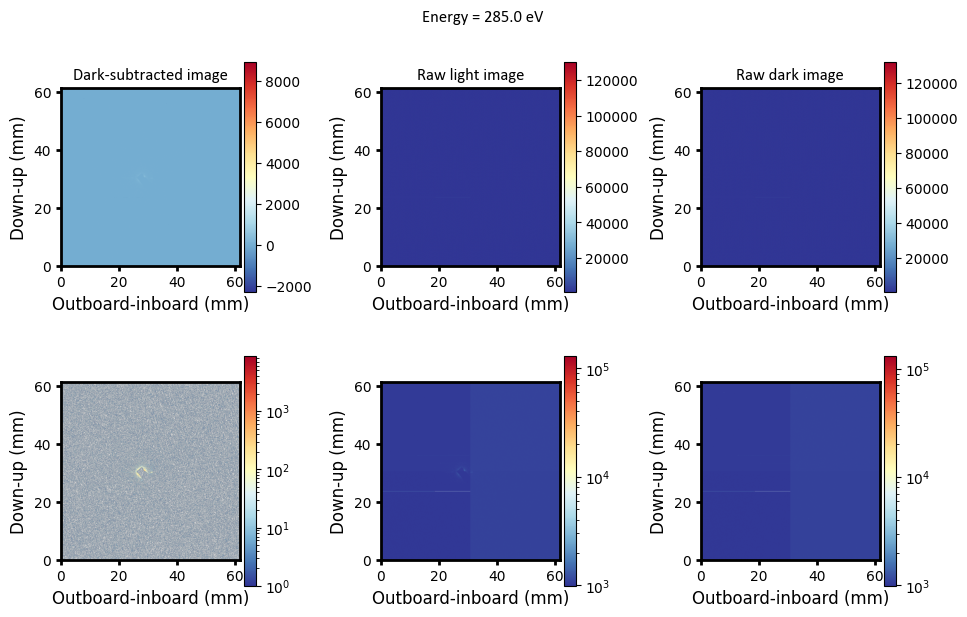

In [4]:
view_single_image(
    scan_id=scan_id,
    energy_view_image = 285,
)

### Draw a mask over unwanted features

If you already have a mask file from beam alignment and do not want to change anything, just run the code below and move to the next block.

If you want to make a custom mask for this sample, do the following. Use the mask drawing tool to conceal parts of the image that are not related to the sample such as the beamstop, slit scattering, etc.  If unable to draw a mask directly onto the image via clicking, hover over the desired vertices and copy the coordinates to an existing mask file.  Note that the pix_y and pix_x seen while hovering over the image; values for pix_y should be entered into the x section of the mask file and vice versa.

In [26]:
scan_single_image = scan.sel(energy=energy_view_image, method="nearest")

from PyHyperScattering.IntegrationUtils import DrawMask
mask = DrawMask(scan_single_image)
mask.ui()

Usage: click the "PolyAnnotator" tool at top right.  DOUBLE CLICK to start drawing a masked object, SINGLE CLICK to add a vertex, then DOUBLE CLICK to finish.  Click/drag individual vertex to adjust.


:Layout
   .DynamicMap.I :DynamicMap   []
      :Overlay
         .Image.I    :Image   [pix_y,pix_x]   (Wide Angle CCD Detector_image)
         .Polygons.I :Polygons   [x,y]   (Label,Value)
   .Annotator.I  :Overlay
      .Table.PolyAnnotator          :Table   [Label]
      .Table.PolyAnnotator_Vertices :Table   [x,y]   (Value)

### Define beam center

This step loads the mask onto the scan and sets a beam center by adjusting the x and y coordinates.  Two rings are plotted on top of the image, and their size can be adjusted such that they are superimposed on top of scattering rings in the scan. It is good to start with strongly scattering sample with clear rings, and then the selected beam center can be used for other samples taken around a similar time as the reference sample.  Even more ideally, an automated beam centering algorithm should be used.

C:\Users\pmk\AppData\Local\miniforge3\envs\20250527_1\Lib\site-packages\PyHyperScattering\PFGeneralIntegrator.py:145: UserWarning: Since mask was none, creating an empty mask with shape (1024, 1026)
  self.calibrationFromTemplateXRParams(template_xr)
C:\Users\pmk\AppData\Local\miniforge3\envs\20250527_1\Lib\site-packages\PyHyperScattering\IntegrationUtils.py:184: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dflist.append(pd.read_json(item))


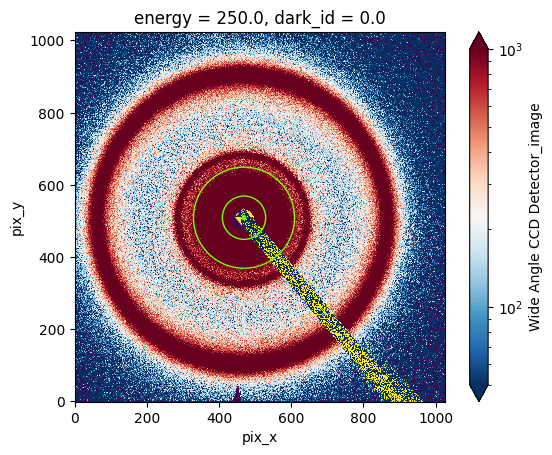

In [27]:
scan_ToIntegrate = phs.integrate.PFEnergySeriesIntegrator(geomethod='template_xr',template_xr = scan)
mask.load(r"BeamstopMask_Format.msk") ## Update mask file path

scan_ToIntegrate.mask = mask.mask
scan_ToIntegrate.npts=400

## Manually change x and y coordinates as well as ring diameters to get the correct beam center
scan_ToIntegrate.ni_beamcenter_x = 469
scan_ToIntegrate.ni_beamcenter_y = 509
phs.IntegrationUtils.Check.checkAll(scan_ToIntegrate,scan_SingleImage,img_min=50,img_max=1000,d_inner=60,d_outer=140)

plt.show()

### Azimuthally integrate data

The points along the same radius are integrated such that the 2D image is collapsed into a 1D plot of intensity (I) vs. scattering vector (q).

In [28]:
scan_AzimuthallyIntegrated = scan_ToIntegrate.integrateImageStack(scan)

100%|████████████████████████████████████████████████████████████████████████████████| 114/114 [02:33<00:00,  1.35s/it]


### Plot I vs. q and export reduced data

C:\Users\pmk\AppData\Local\Temp\ipykernel_10452\3015281849.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() ## This ensures that subplots don't overlap


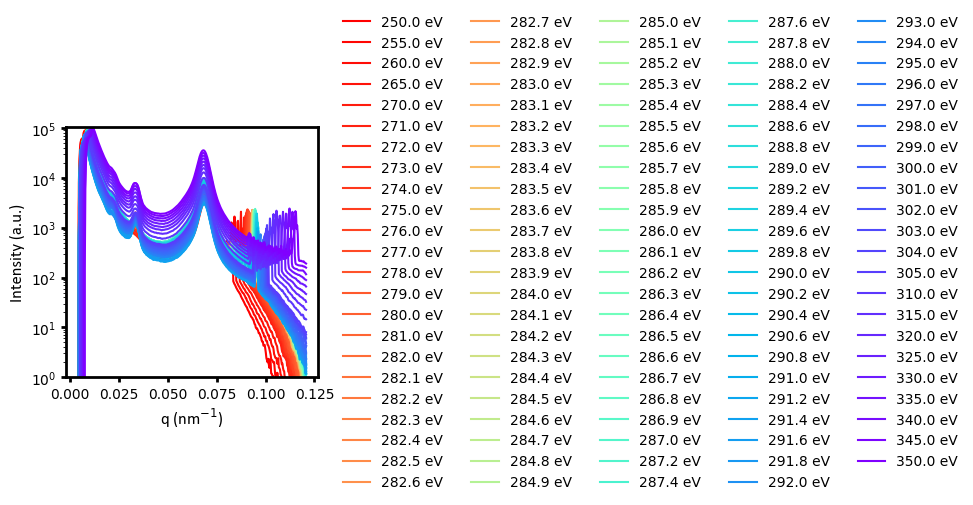

In [29]:
energy_View = "All" #energy_View = 285, energy_View = "All"
#polarization_View = 0

## Export parameters
export = True
filePath_Export = r"G:/Shared drives/NISTPostdoc/CharacterizationData/BeamTime/20250528_SST1_Commissioning/"
fileName_Export = r"Test"

numberRows, numberColumns = 1, 1
fig, axs = plt.subplots(numberRows, numberColumns, figsize=(numberColumns*3.25, numberRows*3.25), edgecolor=(0, 0, 0, 0), linewidth=3); #figsize=(3.25, 3.25) for figure
#fig.suptitle(("Energy = " + str(np.round(Energy_Selected, 2)) + " eV"), color=(0, 0, 0, 1), fontname="Calibri", size=12)
ax = axs

qs, intensities_AzimuthallyIntegrated = {}, {}
energies = np.array(scan_AzimuthallyIntegrated["energy"])
plotColors = cm.rainbow(np.linspace(1, 0, energies.size))
if energy_View == "All": index_EnergyLoop_Start, index_EnergyLoop_End, increment_EnergyLoop = 0, energies.size, 1
else:
    index_EnergyLoop_Start = np.argmin(np.absolute(energies - energy_View))
    index_EnergyLoop_End, increment_EnergyLoop = index_EnergyLoop_Start + 1, 1
for index_Energy in np.arange(index_EnergyLoop_Start, index_EnergyLoop_End, increment_EnergyLoop):
    #energy_Selected, polarization_Selected = energies[index_Energy], polarization_View
    energy_Selected = energies[index_Energy]
    plotLabel = str(round(energy_Selected,3)) + " eV"
    plotColor = plotColors[index_Energy]

    q = scan_AzimuthallyIntegrated.sel(energy=energy_Selected)["q"]
    intensity_AzimuthallyIntegrated = scan_AzimuthallyIntegrated.sel(energy=energy_Selected, chi=slice(-180, 180)).mean("chi").data
    qs[plotLabel], intensities_AzimuthallyIntegrated[plotLabel] = q, intensity_AzimuthallyIntegrated

    ax.plot(q, intensity_AzimuthallyIntegrated, label=plotLabel, marker=".", markersize=0, color=plotColor, linestyle="solid")


## Plot Formatting
numberSubplots = numberRows*numberColumns
for index_Subplot in np.arange(0, numberSubplots, 1):
    if numberSubplots==1: ax = axs
    else: ax = axs.flatten()[index_Subplot]
    ax.set_xlabel("q (nm$^{-1}$)", color=(0, 0, 0, 1), fontname="Calibri", size=12)
    ax.set_ylabel("Intensity (a.u.)", color=(0, 0, 0, 1), fontname="Calibri", size=12)
    ## Axes scaling and ranges
    ax.set_xscale("linear")
    ax.set_ylim(bottom=1)
    #ax.set_xlim([0,0.08])
    ax.set_yscale("log")
    ## Border formatting
    for Border in np.array(["top", "bottom", "left", "right"]):
        ax.spines[Border].set_linewidth(2) ## axes/border linewidths
        ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
    for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis, colors=(0, 0, 0, 1), width=2)
    ax.legend(ncol=5, loc="center left", bbox_to_anchor=(1.05, 0.5), edgecolor=(1, 1, 1, 1)) #ax.legend(edgecolor=(1, 1, 1, 1))
#axs[1, 3].axis('off') ## To remove plot and axes and have a blank spot
plt.tight_layout() ## This ensures that subplots don't overlap
plt.show()

if export:
    timeStamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S") ## Can add timestamp to avoid overwriting different versions of data reduction for the same sample
    fileName_Export = "Reduced" + str(timeStamp) + "_scanID" + str(scanID) + fileName_Export + ".xlsx"

    qs_Dataframe, intensities_AzimuthallyIntegrated_Dataframe = pd.DataFrame(qs), pd.DataFrame(intensities_AzimuthallyIntegrated)
    if os.path.exists(os.path.join(filePath_Export, fileName_Export)):
        with pd.ExcelWriter(os.path.join(filePath_Export, fileName_Export), mode='a') as writer: qs_Dataframe.to_excel(writer, sheet_name="q", index=True)
    else: qs_Dataframe.to_excel(os.path.join(filePath_Export, fileName_Export), sheet_name="q", index=True)
    if os.path.exists(os.path.join(filePath_Export, fileName_Export)):
        with pd.ExcelWriter(os.path.join(filePath_Export, fileName_Export), mode='a') as writer: intensities_AzimuthallyIntegrated_Dataframe.to_excel(writer, sheet_name="intensity", index=True)
    else: intensities_AzimuthallyIntegrated_Dataframe.to_excel(os.path.join(filePath_Export, fileName_Export), sheet_name="intensity", index=True)

## Tests

In [13]:
scan_id = 95929
scan_raw = Catalog[int(scan_id)]
scan_raw.metadata

{'start': {'RSoXS_Config': 'NoBeam',
           'RSoXS_Main_DET': 'WAXS',
           'RSoXS_SAXS_BCX': None,
           'RSoXS_SAXS_BCY': None,
           'RSoXS_SAXS_SDD': None,
           'RSoXS_WAXS_BCX': 467.5,
           'RSoXS_WAXS_BCY': 513.4,
           'RSoXS_WAXS_SDD': 34.34,
           'WAXS_Mask': [[367, 545], [406, 578], [880, 0], [810, 0]],
           'acq_history': [],
           'acquisitions': [{'acquire_status': 'Not begun',
                             'configuration_instrument': 'WAXSNEXAFS',
                             'energy_list_parameters': [270,
                                                        282,
                                                        1.4,
                                                        298,
                                                        0.1,
                                                        335,
                                                        1.4],
                             'exposure_time': 2,
     